In [2]:
# !pip install --upgrade pingouin

In [3]:
# !pip install --upgrade statsmodels

### 2. 라이브러리 참조 

In [4]:
from jussam import load_data
from helpers import *
from pandas import pivot_table

# 분산분석을 위한 라이브러리 
from scipy.stats import f_oneway 
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from pingouin import anova 
from pingouin import welch_anova

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 3. 데이터 가져오기 

In [5]:
origin = load_data('tree_weight')
origin.head()

📚 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,weight,group
0,4.170,A
1,5.580,A
2,5.180,A
3,6.110,A
4,4.500,A


## #02. 데이터 분포 및 가정 확인 

### 1. 데이터분포 

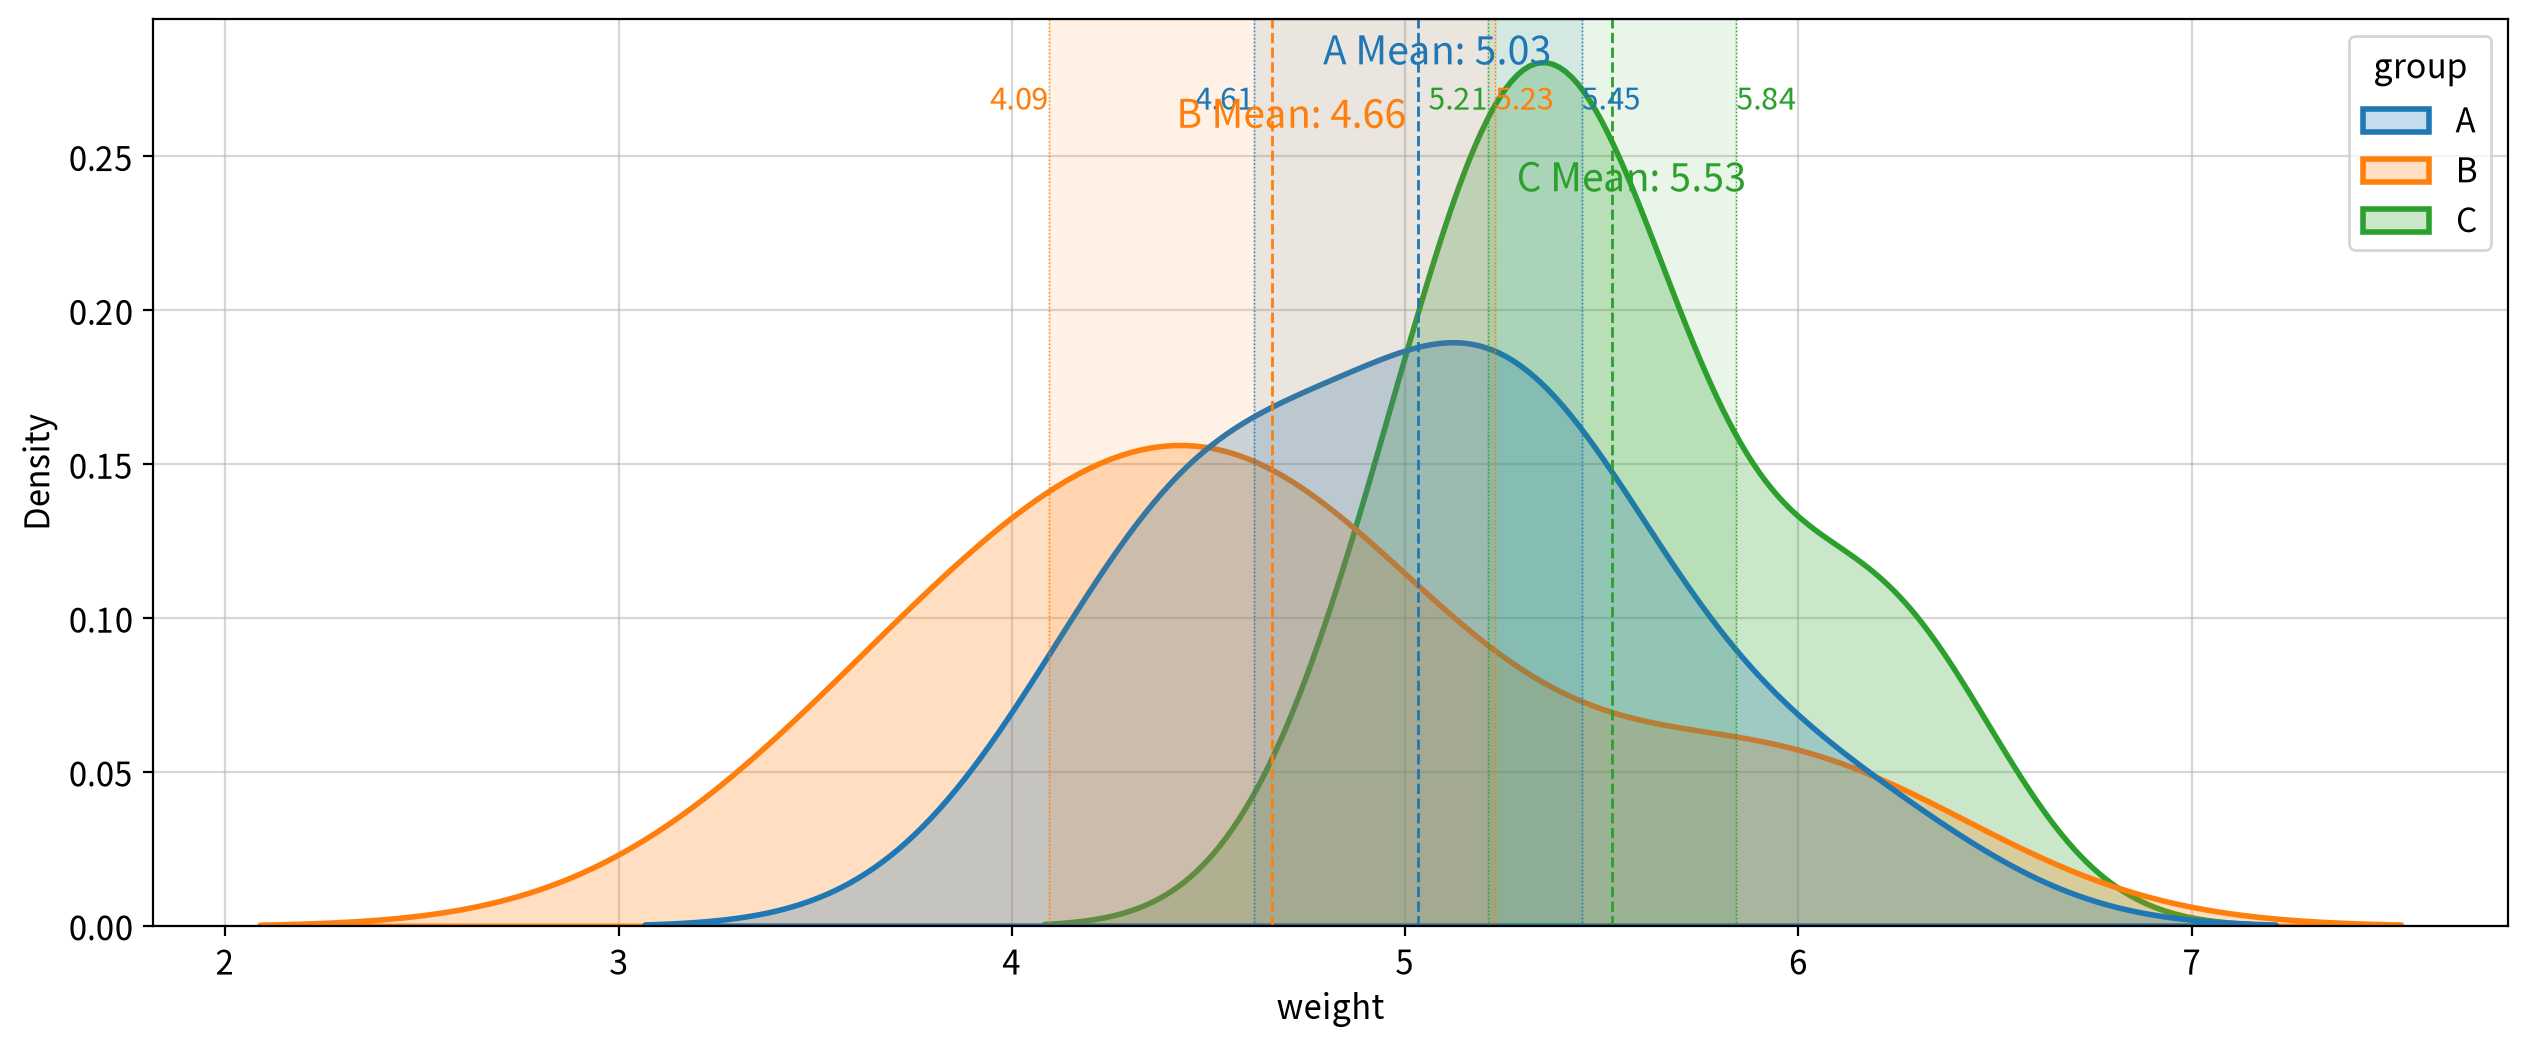

In [6]:
my_plot.kdeplot(origin, x='weight', hue='group', fill=True, 
                meanline=True, clevel=0.95)

### 2. long타입 데이터로 변환 

In [7]:
df_wide = my_prep.long2wide(origin, hue='group', values='weight')
df_wide

,A,B,C
0,4.170,4.810,6.310
1,5.580,4.170,5.120
2,5.180,4.410,5.540
3,6.110,3.590,5.500
4,4.500,5.870,5.370
5,4.610,3.830,5.290
6,5.170,6.030,4.920
7,4.530,4.890,6.150
8,5.330,4.320,5.800
9,5.140,4.690,5.260


### 3. 가설검정의 가정 확인 

In [8]:
my_stats.test_assumptions(df_wide)

,test,statistic,p-value,result
field,,,,
A,normaltest,0.233,0.890,True
B,normaltest,0.968,0.616,True
C,normaltest,1.013,0.603,True
Bartlett,equal_var,2.879,0.237,True


## #03. 일원분산분석 

### 1. SciPy 패키지를 사용하는 경우 

In [9]:
s, p = f_oneway(df_wide['A'], df_wide['B'], df_wide['C'], 
                equal_var=True)
"statistic : {0:.3f}, p-value : {1:.3f}".format(s, p)

'statistic : 4.846, p-value : 0.016'

### 2. statsmodels 패키지를 사용하는 경우 

In [10]:
# 연속형 변수 이름 ~ C(그룹변수이름) 
lm = ols ( 'weight ~ C(group)', data=origin).fit()
anova_result = anova_lm(lm)
anova_result

,df,sum_sq,mean_sq,F,PR(>F)
C(group),2.000,3.766,1.883,4.846,0.016
Residual,27.000,10.492,0.389,NaN,NaN


### 3. pingouin 패키지 사용(1) - 등분산성을 충족하는 경우 

In [11]:
anova_result = anova(data=origin, dv='weight', between='group')
anova_result

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,27,4.846,0.016,0.264


### 4. pingouin 패키지 사용(2) - 등분산성을 충족하지 않는 경우 

In [12]:
welch_anova(data=origin, dv='weight', between='group')

,Source,ddof1,ddof2,F,p_unc,np2
0,group,2,17.128,5.181,0.017,0.264


## #04. 모듈화 기능 확인 

In [13]:
my_stats.anova_oneway(origin, y='weight', between='group')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,group,2,27,4.846,0.016,0.264,Large


## #01. 연습문제 

In [15]:
origin = load_data("reading")
origin.head()

📚 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)


,독서방법,점수
0,B,7.700
1,B,1.500
2,B,4.300
3,B,5.400
4,B,4.300


In [16]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   독서방법    90 non-null     str    
 1   점수      90 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


In [17]:
origin.describe()

,점수
count,90.000
mean,8.470
std,5.744
min,0.000
25%,5.100
50%,7.600
75%,9.400
max,26.300


In [18]:
my_stats.anova_oneway(origin, y='점수', between='독서방법')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,독서방법,2,48.204,10.787,0.000,0.283,Large


### 💡인사이트

- **가정 확인**: `anova_oneway` 함수는 분석에 앞서 정규성(normaltest)과 등분산성 검정을 수행한다. 결과표의 `test`가 `welch_anova`로 출력되었다는 것은 **등분산성 가정이 위배(불충족)**되어, 등분산을 가정하지 않는 **Welch-ANOVA**가 자동 선택되었음을 의미한다. (등분산이 충족되면 일반 `anova`가 선택된다.)
- **검정 결과**: F(2, 48.204) = 10.787, p ≈ 0.000 으로 유의수준 0.05보다 작다. 따라서 "세 독서방법의 평균 점수가 모두 같다"는 귀무가설을 **기각**한다. 즉, **세 가지 읽는 방법에 따른 독서평가 점수에는 통계적으로 유의한 차이가 있다.**
- **효과크기**: 부분 에타제곱(np2) = 0.283 으로 0.14 이상에 해당하여 **큰 효과(Large)**로 해석된다. 독서방법이 점수 분산의 약 28.3%를 설명한다.
- **결론**: 독서방법은 독서평가 점수에 유의하고 큰 영향을 미친다. 다만 분산분석은 "어느 집단들 사이에" 차이가 있는지는 알려주지 않으므로, 구체적인 집단 쌍 간 차이를 확인하려면 사후검정(`posthoc_oneway`)이 필요하다.


## #02. 연습문제 

In [27]:
origin = load_data("commercial")
origin.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


In [28]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 6222 entries, 0 to 6221
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   quarter          6222 non-null   int64
 1   code             6222 non-null   int64
 2   type             6222 non-null   str  
 3   name             6222 non-null   str  
 4   sales_amount     6222 non-null   int64
 5   number_of_sales  6222 non-null   int64
dtypes: int64(4), str(2)
memory usage: 489.8 KB


In [29]:
origin.describe()

,quarter,code,sales_amount,number_of_sales
count,6222.000,6222.000,6222.000,6222.000
mean,2.500,3115154.611,14308345425.458,501584.766
std,1.118,10394.649,48942597362.898,1173159.189
min,1.000,3001491.000,66624.000,3.000
25%,2.000,3110407.000,967327537.750,37271.500
50%,3.000,3110815.000,3224000449.000,163532.000
75%,3.750,3120138.000,9851680897.500,452118.750
max,4.000,3130327.000,1077120667896.000,20311112.000


In [37]:
# 상권종류별 -> groupby("type")
origin.groupby('type')['sales_amount'].mean()


type
골목상권     3659508698.643
관광특구   228143191041.625
발달상권    57063096491.533
전통시장    10584197874.740
Name: sales_amount, dtype: float64

In [38]:
my_stats.anova_oneway(origin, y='sales_amount', between='type')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,type,3,110.239,161.433,0.000,0.228,Large


### 💡인사이트

- **가정 확인**: `anova_oneway` 함수가 정규성과 등분산성 검정을 수행한 뒤 `test`를 `welch_anova`로 출력하였다. 이는 상권 종류별 매출액의 **등분산성 가정이 위배**되어 **Welch-ANOVA**가 자동 선택되었음을 의미한다. (문제 조건상 결측치·이상치 정제는 생략하였다.)
- **검정 결과**: F(3, 110.239) = 161.433, p ≈ 0.000 으로 유의수준 0.05보다 작다. 따라서 "네 가지 상권 종류(발달상권·골목상권·관광특구·전통시장)의 평균 매출액이 모두 같다"는 귀무가설을 **기각**한다. 즉, **상권 종류에 따라 2023년 평균 매출액에는 통계적으로 유의한 차이가 존재한다.**
- **효과크기**: 부분 에타제곱(np2) = 0.228 로 0.14 이상에 해당하여 **큰 효과(Large)**로 해석된다. 상권 종류가 매출액 분산의 약 22.8%를 설명한다.
- **결론**: 상권 종류는 2023년 평균 매출액에 유의하고 큰 차이를 만든다. 어떤 상권 종류들 사이에서 차이가 두드러지는지는 분산분석만으로 알 수 없으므로, 구체적 비교를 위해서는 사후검정(`posthoc_oneway`)을 추가로 수행해야 한다.
